In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sensofit.data_loader import load_cxw
from sensofit.models import (
    build_concentration_profile, build_pulsed_concentration_profile,
    select_dmso_cal, select_blank,
    double_reference, build_weight_mask, build_full_weight_mask,
    smooth_and_differentiate,
    simulate_sensorgram, is_nonspecific_binder
)
from sensofit.direct_kinetics import fit_sample as dk_fit_sample
from sensofit.ode_fitting import fit_sample as ode_fit_sample

In [2]:
CXW = "/mnt/c/Users/kgr26424/Documents/Creoptix_test/SensoFit_test/2026.03.18/20260318_EV71 2A Binding assay.cxw"
data = load_cxw(CXW)
samples = data['samples']
dmso_cals = data['dmso_cals']
blanks = data['blanks']

In [3]:
def find_sample(name, conc_uM=None):
    """Find a sample by compound name (substring match), optionally filter by concentration.
    If multiple matches, prompts user to choose."""
    hits = [(i, s) for i, s in enumerate(samples) if name in s['compound']]
    if conc_uM is not None:
        hits = [(i, s) for i, s in hits if abs(s['concentration_M'] * 1e6 - conc_uM) < 0.01]
    if not hits:
        raise ValueError(f'No sample found matching "{name}"' + (f' at {conc_uM} µM' if conc_uM else ''))
    if len(hits) == 1:
        return hits[0][1]
    # Multiple matches — ask user to pick
    print(f'Multiple matches for "{name}":')
    for j, (idx, s) in enumerate(hits):
        nsb, _ = is_nonspecific_binder(s)
        tag = ' [NSB]' if nsb else ''
        print(f'  [{j}] samples[{idx}]  {s["compound"]}  {s["concentration_M"]*1e6:.0f} µM  (cycle {s["index"]}){tag}')
    choice = int(input(f'Select [0–{len(hits)-1}]: '))
    return hits[choice][1]

In [4]:
# --- Select sample here ---
sample = find_sample('ASAP-0043110') 
print(f'Sample: {sample["compound"]}  ({sample["concentration_M"]*1e6:.2f} µM, cycle {sample["index"]})')

Multiple matches for "ASAP-0043110":
  [0] samples[27]  ASAP-0043110-001  0 µM  (cycle 22)
  [1] samples[28]  ASAP-0043110-001  0 µM  (cycle 22)
  [2] samples[29]  ASAP-0043110-001  0 µM  (cycle 22)


Select [0–2]:  1


Sample: ASAP-0043110-001  (0.25 µM, cycle 22)


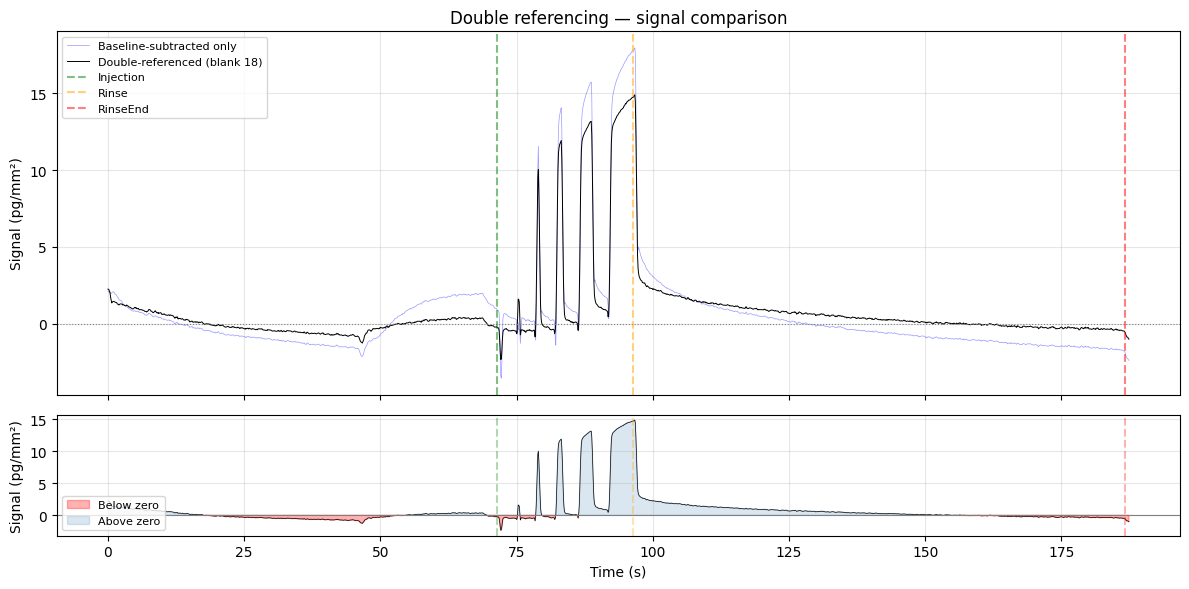

Pre-injection baseline mean: -0.000000 pg/mm² (always 0 by construction)
Signal range: [-2.35, 14.90] pg/mm²
Points below zero: 801/1875 (42.7%)
Dissociation min:  -0.59 pg/mm²


In [5]:
# --- Double Reference ---
t = sample['time']
inj_time = sample['markers'].get('Injection', t[0])
rinse_time = sample['markers'].get('Rinse', t[-1])
rinse_end = sample['markers'].get('RinseEnd', t[-1])

# Baseline-subtracted raw signal (no blank)
bl_mask = t < inj_time
sig_raw = sample['signal'] - sample['signal'][bl_mask].mean()

# Double-referenced signal
sig_dr, blank_idx = double_reference(sample, blanks)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

t_double_ref = t
sig_double_ref = sig_dr
# --- Top: signal comparison ---
axes[0].plot(t, sig_raw, 'b-', lw=0.5, alpha=0.4, label='Baseline-subtracted only')
axes[0].plot(t, sig_dr, 'k-', lw=0.7, label=f'Double-referenced (blank {blank_idx})')
axes[0].axhline(0, color='gray', ls=':', lw=0.8)
for name, col in [('Injection', 'green'), ('Rinse', 'orange'), ('RinseEnd', 'red')]:
    if name in sample['markers']:
        axes[0].axvline(sample['markers'][name], color=col, ls='--', alpha=0.5, label=name)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title('Double referencing — signal comparison')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# --- Bottom: highlight where double-ref signal goes negative ---
neg_mask = sig_dr < 0
axes[1].fill_between(t, sig_dr, 0, where=neg_mask, color='red', alpha=0.3, label='Below zero')
axes[1].fill_between(t, sig_dr, 0, where=~neg_mask, color='steelblue', alpha=0.2, label='Above zero')
axes[1].plot(t, sig_dr, 'k-', lw=0.5)
axes[1].axhline(0, color='gray', lw=0.8)
for name, col in [('Injection', 'green'), ('Rinse', 'orange'), ('RinseEnd', 'red')]:
    if name in sample['markers']:
        axes[1].axvline(sample['markers'][name], color=col, ls='--', alpha=0.3)
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Signal (pg/mm²)')
axes[1].legend(fontsize=8, loc='lower left')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

pct_neg = neg_mask.sum() / len(sig_dr) * 100
print(f'Pre-injection baseline mean: {sig_dr[bl_mask].mean():.6f} pg/mm² (always 0 by construction)')
print(f'Signal range: [{sig_dr.min():.2f}, {sig_dr.max():.2f}] pg/mm²')
print(f'Points below zero: {neg_mask.sum()}/{len(sig_dr)} ({pct_neg:.1f}%)')
print(f'Dissociation min:  {sig_dr[(t >= rinse_time) & (t <= rinse_end)].min():.2f} pg/mm²')

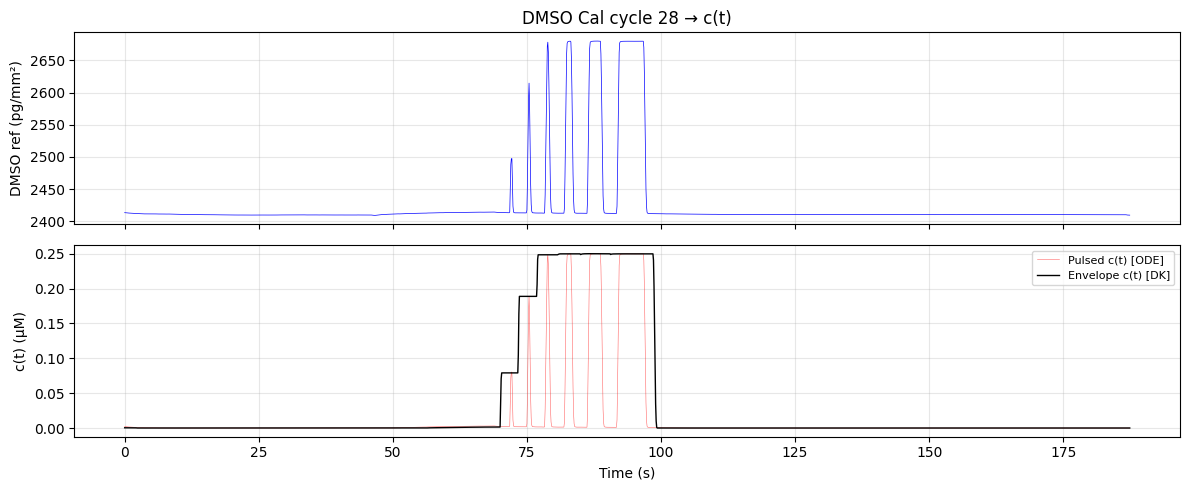

In [6]:
# --- Concentration function ---
dmso = select_dmso_cal(sample['index'], dmso_cals)
c_func_env, c_raw_env = build_concentration_profile(dmso, sample['concentration_M'])
c_func_pulsed, c_raw_pulsed = build_pulsed_concentration_profile(dmso, sample['concentration_M'])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

t_d = dmso['time']
ax1.plot(t_d, dmso['raw_reference'], 'b-', lw=0.5)
ax1.set_ylabel('DMSO ref (pg/mm²)')
ax1.set_title(f'DMSO Cal cycle {dmso["index"]} → c(t)')
ax1.grid(True, alpha=0.3)

ax2.plot(t_d, c_raw_pulsed * 1e6, 'r-', lw=0.4, alpha=0.6, label='Pulsed c(t) [ODE]')
ax2.plot(t_d, c_raw_env * 1e6, 'k-', lw=1.0, label='Envelope c(t) [DK]')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('c(t) (µM)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# --- Direct Kinetics ---
dk = dk_fit_sample(sample, dmso_cals, blanks=blanks)

print('=== Direct Kinetics Results ===')
print(f'  ka   = {dk["ka"]:.2e} M⁻¹s⁻¹')
print(f'  kd   = {dk["kd"]:.4f} s⁻¹')
print(f'  Rmax = {dk["Rmax"]:.1f} pg/mm²')
print(f'  KD   = {dk["KD"]*1e6:.2f} µM')
print(f'  R0   = {dk["R0_dissoc"]:.1f} pg/mm² (at rinse)')
print(f'  σ    = {dk["sigma_residual"]:.3f} pg/mm²')

=== Direct Kinetics Results ===
  ka   = 1.23e+05 M⁻¹s⁻¹
  kd   = 0.0452 s⁻¹
  Rmax = 15.3 pg/mm²
  KD   = 0.37 µM
  R0   = 14.6 pg/mm² (at rinse)
  σ    = 3.044 pg/mm²


In [8]:
def _contiguous_spans(t, mask):
    """Yield (start, end) time spans for contiguous True runs in mask."""
    spans = []
    in_span = False
    for i, v in enumerate(mask):
        if v and not in_span:
            start = t[i]
            in_span = True
        elif not v and in_span:
            spans.append((start, t[i - 1]))
            in_span = False
    if in_span:
        spans.append((start, t[-1]))
    return spans

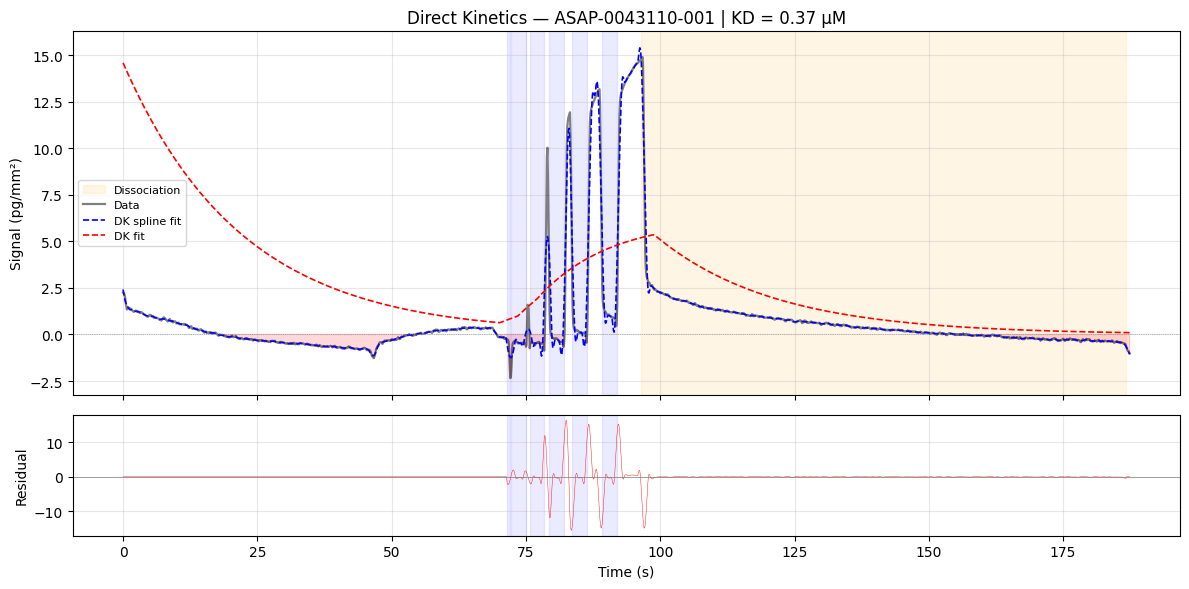

In [9]:
# --- DK - Goodness of fit ---
# Plot DK smoothed fit vs data
t_dk = dk['t']
sig_dk = dk['signal']
R_smooth = dk['R_smooth']
simulate_dk = simulate_sensorgram(t_dk, dk["ka"], dk["kd"], dk["Rmax"], c_func_env, dk["R0_dissoc"])
w_dk = build_weight_mask(t_dk, sample['markers'])

# Full weight mask to show buffer-pulse intervals (for reference)
w_full = build_full_weight_mask(t_dk, sample['markers'], dmso)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Shade all fitted regions (buffer pulses + dissociation)
buf_mask = (w_full > 0) & (w_dk == 0)
for start, end in _contiguous_spans(t_dk, buf_mask):
    axes[0].axvspan(start, end, alpha=0.08, color='blue')
    axes[1].axvspan(start, end, alpha=0.08, color='blue')
axes[0].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange', label='Dissociation')

# Shade negative regions of data
neg_dk = sig_dk < 0
axes[0].fill_between(t_dk, sig_dk, 0, where=neg_dk, color='red', alpha=0.15)

axes[0].plot(t_dk, sig_dk, 'k-', lw=1.6, alpha=0.5, label='Data')
axes[0].plot(t_dk, R_smooth, 'b--', lw=1.2, label='DK spline fit')
axes[0].plot(t_dk, simulate_dk, 'r--', lw=1.2, label='DK fit')
axes[0].axhline(0, color='gray', ls=':', lw=0.5)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title(f'Direct Kinetics — {sample["compound"]} | KD = {dk["KD"]*1e6:.2f} µM')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_dk, dk['residuals'], 'r-', lw=0.3)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
def chi2(exp, fit, dof=3):
    if len(exp) > len(fit):
        exp = exp[:len(fit)]
    elif len(fit) > len(exp):
        fit = fit[:len(exp)]
    assert len(exp) == len(fit)
    residuals = exp - fit
    sigma = np.std(exp)
    chi2 = np.sum((residuals / sigma)**2)
    return chi2 / dof

def r_squared(exp, fit):
    if len(exp) > len(fit):
        exp = exp[:len(fit)]
    elif len(fit) > len(exp):
        fit = fit[:len(exp)]
    assert len(exp) == len(fit)
    ss_res = np.sum((exp - fit) ** 2)
    ss_tot = np.sum((exp - np.mean(exp)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    return r_squared
        
def rmse(exp, fit, p=3):
    if len(exp) > len(fit):
        exp = exp[:len(fit)]
    elif len(fit) > len(exp):
        fit = fit[:len(exp)]
    assert len(exp) == len(fit)
    ss_res = np.sum((exp - fit) ** 2)
    rmse = np.sqrt(ss_res/(len(exp)-p))
    return rmse

In [11]:
dk_chi2 = chi2(R_smooth, simulate_dk, dof=3)
dk_r2 = r_squared(R_smooth, simulate_dk)
dk_rmse = rmse(R_smooth, simulate_dk, p=3)

print('=== DK Goodness of Fit ===')
print(f'  Chi2 = {dk_chi2:.3f}')
print(f'  R2   = {dk_r2:.3f}')
print(f'  RMSE = {dk_rmse:.3f}')

=== DK Goodness of Fit ===
  Chi2 = 1363.801
  R2   = -1.182
  RMSE = 3.970


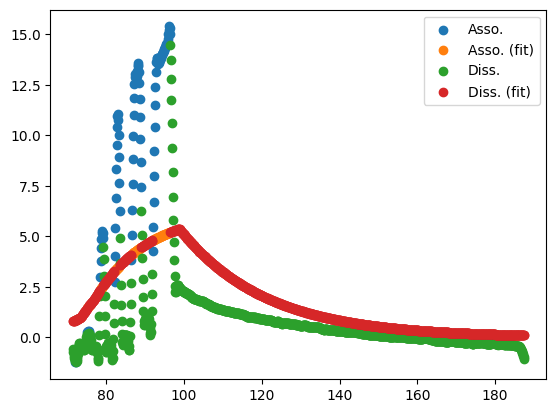

In [12]:
dk_data = {"time": t_dk, "raw_R": sig_dk, "smooth_R": R_smooth, "simulate_R": simulate_dk}
injection_mask = dk_data["time"] >= inj_time

for key in dk_data:
    dk_data[key] = dk_data[key][injection_mask]

dissociation_mask = buf_mask[injection_mask]
dissociation_mask |= (dk_data["time"] >= rinse_time)

dissociation_data = {
    key: values[dissociation_mask]
    for key, values in dk_data.items()
}

association_data = {
    key: values[~dissociation_mask]
    for key, values in dk_data.items()
}
plt.scatter(association_data["time"], association_data["smooth_R"], label="Asso.")
plt.scatter(association_data["time"], association_data["simulate_R"], label="Asso. (fit)")
plt.scatter(dissociation_data["time"], dissociation_data["smooth_R"], label="Diss.")
plt.scatter(dissociation_data["time"], dissociation_data["simulate_R"], label="Diss. (fit)")
plt.legend()
plt.show()

In [13]:
dk_chi2_diss = chi2(dissociation_data["smooth_R"], dissociation_data["simulate_R"], dof=3)
dk_r2_diss = r_squared(dissociation_data["smooth_R"], dissociation_data["simulate_R"])
dk_rmse_diss = rmse(dissociation_data["smooth_R"], dissociation_data["simulate_R"], p=3)

dk_chi2_asso = chi2(association_data["smooth_R"], association_data["simulate_R"], dof=3)
dk_r2_asso = r_squared(association_data["smooth_R"], association_data["simulate_R"])
dk_rmse_asso = rmse(association_data["smooth_R"], association_data["simulate_R"], p=3)

print('=== DK Goodness of Fit ===')
print(f' Chi2 (diss. only) = {dk_chi2_diss:.3f}')
print(f' Chi2 (asso. only) = {dk_chi2_asso:.3f}')
print(f' R2   (diss. only) = {dk_r2_diss:.3f}')
print(f' R2   (asso. only) = {dk_r2_asso:.3f}')
print(f' RMSE (diss. only) = {dk_rmse_diss:.3f}')
print(f' RMSE (asso. only) = {dk_rmse_asso:.3f}')

=== DK Goodness of Fit ===
 Chi2 (diss. only) = 554.003
 Chi2 (asso. only) = 81.329
 R2   (diss. only) = -0.568
 R2   (asso. only) = -1.440
 RMSE (diss. only) = 1.619
 RMSE (asso. only) = 7.206


In [14]:
# --- ODE ---
ode = ode_fit_sample(sample, dmso_cals, blanks=blanks, n_starts=1)

print('=== ODE Refinement Results ===')
print(f'  ka   = {ode["ka"]:.2e} M⁻¹s⁻¹  (DK: {ode["dk_ka"]:.2e})')
print(f'  kd   = {ode["kd"]:.4f} s⁻¹      (DK: {ode["dk_kd"]:.4f})')
print(f'  Rmax = {ode["Rmax"]:.1f} pg/mm²   (DK: {ode["dk_Rmax"]:.1f})')
print(f'  KD   = {ode["KD"]*1e6:.2f} µM     (DK: {ode["dk_KD"]*1e6:.2f})')
print(f'  R0   = {ode["R0"]:.1f},  Rss = {ode["Rss"]:.2f} pg/mm²')
print(f'  σ    = {ode["sigma_residual"]:.3f} pg/mm²')
print(f'  {ode["message"]}')
if not np.isnan(ode.get('ka_se', np.nan)):
    print(f'  ka SE   = {ode["ka_se"]:.2e}')
    print(f'  kd SE   = {ode["kd_se"]:.2e}')
    print(f'  Rmax SE = {ode["Rmax_se"]:.2f}')

=== ODE Refinement Results ===
  ka   = 2.56e+03 M⁻¹s⁻¹  (DK: 1.23e+05)
  kd   = 0.0752 s⁻¹      (DK: 0.0452)
  Rmax = 1337.2 pg/mm²   (DK: 15.3)
  KD   = 29.35 µM     (DK: 0.37)
  R0   = 2.9,  Rss = -0.24 pg/mm²
  σ    = 0.965 pg/mm²
  2/1 ODE starts converged
  ka SE   = 4.02e+04
  kd SE   = 4.25e-03
  Rmax SE = 66588.99


Weighted points: 1053 total  (150 buffer pulses + 903 dissociation)


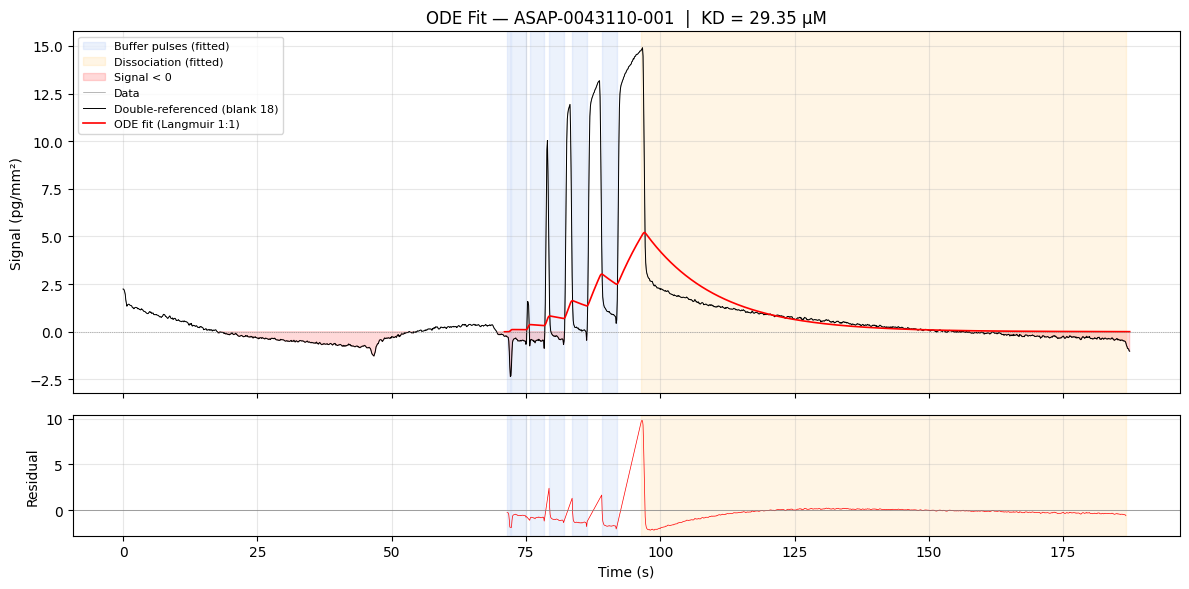

In [15]:
# Overlay ODE fit on data — full sensorgram with all weighted regions
t_ode = ode['t']
sig_ode = ode['signal']
R_fit = ode['R_fit']

# Full weight mask (buffer pulses during association + dissociation)
w_ode = build_full_weight_mask(t_ode, sample['markers'], dmso)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Shade all fitted regions
buf_mask = (w_ode > 0) & (t_ode < rinse_time)
dissoc_mask_plot = (t_ode >= rinse_time) & (t_ode <= rinse_end)

for start, end in _contiguous_spans(t_ode, buf_mask):
    axes[0].axvspan(start, end, alpha=0.12, color='cornflowerblue')
    axes[1].axvspan(start, end, alpha=0.12, color='cornflowerblue')
axes[0].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')
axes[1].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')

# Legend entries for shading
axes[0].fill_between([], [], alpha=0.12, color='cornflowerblue', label='Buffer pulses (fitted)')
axes[0].fill_between([], [], alpha=0.1, color='orange', label='Dissociation (fitted)')

# Shade negative regions of data
neg_ode = sig_ode < 0
axes[0].fill_between(t_ode, sig_ode, 0, where=neg_ode, color='red', alpha=0.15,
                     label='Signal < 0')

axes[0].plot(t_ode, sig_ode, 'k-', lw=0.4, alpha=0.5, label='Data')
axes[0].plot(t, sig_dr, 'k-', lw=0.7, label=f'Double-referenced (blank {blank_idx})')
axes[0].plot(t_ode, R_fit, 'r-', lw=1.2, label='ODE fit (Langmuir 1:1)')
axes[0].axhline(0, color='gray', ls=':', lw=0.5)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title(f'ODE Fit — {sample["compound"]}  |  '
                  f'KD = {ode["KD"]*1e6:.2f} µM')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Residuals for all weighted points (buffer pulses + dissociation)
residuals_full = ode['residuals']
weighted_mask = w_ode > 0
axes[1].plot(t_ode[weighted_mask], residuals_full[weighted_mask], 'r-', lw=0.5)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

n_buf = buf_mask.sum()
n_dissoc = dissoc_mask_plot.sum()
n_total = weighted_mask.sum()
print(f'Weighted points: {n_total} total  ({n_buf} buffer pulses + {n_dissoc} dissociation)')

plt.tight_layout()
plt.show()

In [16]:
# --- ODE - Goodness of fit ---
ode_data = {"time": t_ode, "raw_R": sig_ode, "simulate_R": R_fit}
for key in ode_data:
    ode_data[key] = ode_data[key][injection_mask]
    
ode_chi2 = chi2(ode_data["raw_R"], ode_data["simulate_R"], dof=3)
ode_r2 = r_squared(ode_data["raw_R"], ode_data["simulate_R"])
ode_rmse = rmse(ode_data["raw_R"], ode_data["simulate_R"], p=3)

print('=== ODE Goodness of Fit ===')
print(f'  Chi2 = {ode_chi2:.3f}')
print(f'  R2   = {ode_r2:.3f}')
print(f'  RMSE = {ode_rmse:.3f}')

=== ODE Goodness of Fit ===
  Chi2 = 257.391
  R2   = 0.334
  RMSE = 2.745


In [17]:
dissociation_data = {
    key: values[dissociation_mask]
    for key, values in ode_data.items()
}

association_data = {
    key: values[~dissociation_mask]
    for key, values in ode_data.items()
}

dk_chi2_diss = chi2(dissociation_data["raw_R"], dissociation_data["simulate_R"], dof=3)
dk_r2_diss = r_squared(dissociation_data["raw_R"], dissociation_data["simulate_R"])
dk_rmse_diss = rmse(dissociation_data["raw_R"], dissociation_data["simulate_R"], p=3)

dk_chi2_asso = chi2(association_data["raw_R"], association_data["simulate_R"], dof=3)
dk_r2_asso = r_squared(association_data["raw_R"], association_data["simulate_R"])
dk_rmse_asso = rmse(association_data["raw_R"], association_data["simulate_R"], p=3)

print('=== DK Goodness of Fit ===')
print(f' Chi2 (diss. only) = {dk_chi2_diss:.3f}')
print(f' Chi2 (asso. only) = {dk_chi2_asso:.3f}')
print(f' R2   (diss. only) = {dk_r2_diss:.3f}')
print(f' R2   (asso. only) = {dk_r2_asso:.3f}')
print(f' RMSE (diss. only) = {dk_rmse_diss:.3f}')
print(f' RMSE (asso. only) = {dk_rmse_asso:.3f}')

=== DK Goodness of Fit ===
 Chi2 (diss. only) = 195.245
 Chi2 (asso. only) = 119.591
 R2   (diss. only) = 0.447
 R2   (asso. only) = -2.588
 RMSE (diss. only) = 0.964
 RMSE (asso. only) = 8.930


In [18]:
# --- ODE - Impact of baseline correction ---
ode = ode_fit_sample(sample, dmso_cals, blanks=blanks, neg_ss_correction=True, n_starts=1)

print('=== ODE Refinement Results ===')
print(f'  ka   = {ode["ka"]:.2e} M⁻¹s⁻¹  (DK: {ode["dk_ka"]:.2e})')
print(f'  kd   = {ode["kd"]:.4f} s⁻¹      (DK: {ode["dk_kd"]:.4f})')
print(f'  Rmax = {ode["Rmax"]:.1f} pg/mm²   (DK: {ode["dk_Rmax"]:.1f})')
print(f'  KD   = {ode["KD"]*1e6:.2f} µM     (DK: {ode["dk_KD"]*1e6:.2f})')
print(f'  R0   = {ode["R0"]:.1f},  Rss = {ode["Rss"]:.2f} pg/mm²')
print(f'  σ    = {ode["sigma_residual"]:.3f} pg/mm²')
print(f'  {ode["message"]}')
if not np.isnan(ode.get('ka_se', np.nan)):
    print(f'  ka SE   = {ode["ka_se"]:.2e}')
    print(f'  kd SE   = {ode["kd_se"]:.2e}')
    print(f'  Rmax SE = {ode["Rmax_se"]:.2f}')

=== ODE Refinement Results ===
  ka   = 1.79e+04 M⁻¹s⁻¹  (DK: 1.23e+05)
  kd   = 0.0400 s⁻¹      (DK: 0.0452)
  Rmax = 147.6 pg/mm²   (DK: 15.3)
  KD   = 2.24 µM     (DK: 0.37)
  R0   = 2.9,  Rss = 0.35 pg/mm²
  σ    = 0.925 pg/mm²
  2/1 ODE starts converged
  ka SE   = 1.32e+05
  kd SE   = 1.68e-03
  Rmax SE = 2720.30


Weighted points: 1053 total  (150 buffer pulses + 903 dissociation)


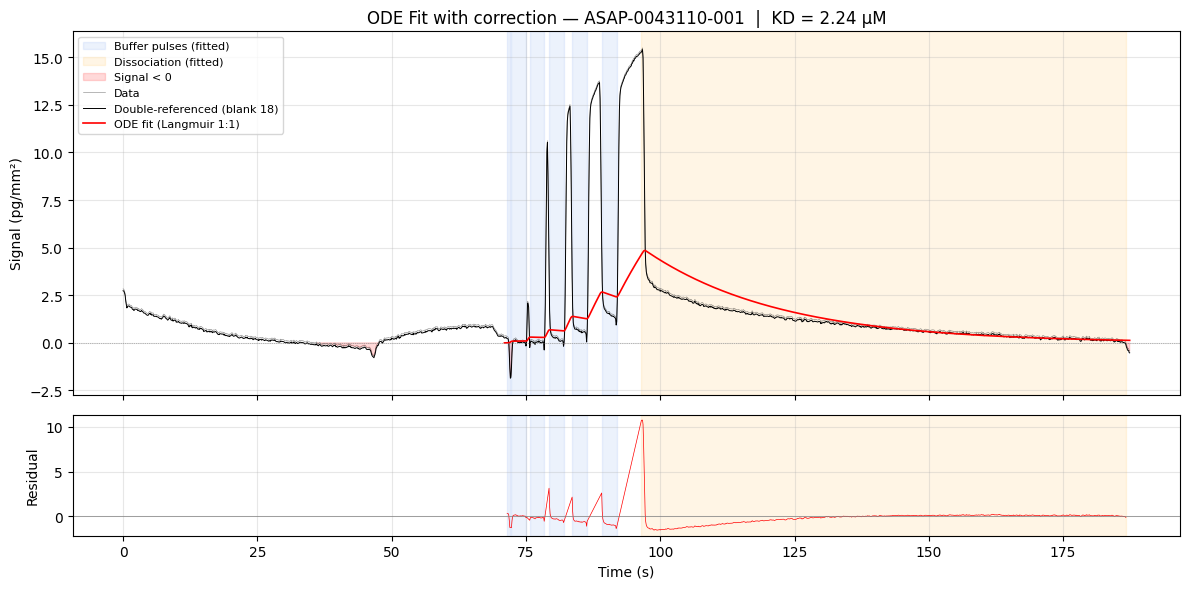

In [19]:
# Overlay ODE fit on data — full sensorgram with all weighted regions
t_ode = ode['t']
sig_ode = ode['signal']
R_fit = ode['R_fit']

# Full weight mask (buffer pulses during association + dissociation)
w_ode = build_full_weight_mask(t_ode, sample['markers'], dmso)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

# Shade all fitted regions
buf_mask = (w_ode > 0) & (t_ode < rinse_time)
dissoc_mask_plot = (t_ode >= rinse_time) & (t_ode <= rinse_end)

for start, end in _contiguous_spans(t_ode, buf_mask):
    axes[0].axvspan(start, end, alpha=0.12, color='cornflowerblue')
    axes[1].axvspan(start, end, alpha=0.12, color='cornflowerblue')
axes[0].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')
axes[1].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')

# Legend entries for shading
axes[0].fill_between([], [], alpha=0.12, color='cornflowerblue', label='Buffer pulses (fitted)')
axes[0].fill_between([], [], alpha=0.1, color='orange', label='Dissociation (fitted)')

# Shade negative regions of data
neg_ode = sig_ode < 0
axes[0].fill_between(t_ode, sig_ode, 0, where=neg_ode, color='red', alpha=0.15,
                     label='Signal < 0')

axes[0].plot(t_ode, sig_ode, 'k-', lw=0.4, alpha=0.5, label='Data')
axes[0].plot(t, [s - -0.49395999508851673 for s in sig_dr], 'k-', lw=0.7, label=f'Double-referenced (blank {blank_idx})')
axes[0].plot(t_ode, R_fit, 'r-', lw=1.2, label='ODE fit (Langmuir 1:1)')
axes[0].axhline(0, color='gray', ls=':', lw=0.5)
axes[0].set_ylabel('Signal (pg/mm²)')
axes[0].set_title(f'ODE Fit with correction — {sample["compound"]}  |  '
                  f'KD = {ode["KD"]*1e6:.2f} µM')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Residuals for all weighted points (buffer pulses + dissociation)
residuals_full = ode['residuals']
weighted_mask = w_ode > 0
axes[1].plot(t_ode[weighted_mask], residuals_full[weighted_mask], 'r-', lw=0.5)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_ylabel('Residual')
axes[1].set_xlabel('Time (s)')
axes[1].grid(True, alpha=0.3)

n_buf = buf_mask.sum()
n_dissoc = dissoc_mask_plot.sum()
n_total = weighted_mask.sum()
print(f'Weighted points: {n_total} total  ({n_buf} buffer pulses + {n_dissoc} dissociation)')

plt.tight_layout()
plt.show()

In [20]:
# --- ODE - Goodness of fit ---
ode_data = {"time": t_ode, "raw_R": sig_ode, "simulate_R": R_fit}
for key in ode_data:
    ode_data[key] = ode_data[key][injection_mask]
    
ode_chi2 = chi2(ode_data["raw_R"], ode_data["simulate_R"], dof=3)
ode_r2 = r_squared(ode_data["raw_R"], ode_data["simulate_R"])
ode_rmse = rmse(ode_data["raw_R"], ode_data["simulate_R"], p=3)

print('=== ODE Goodness of Fit ===')
print(f'  Chi2 = {ode_chi2:.3f}')
print(f'  R2   = {ode_r2:.3f}')
print(f'  RMSE = {ode_rmse:.3f}')

=== ODE Goodness of Fit ===
  Chi2 = 296.030
  R2   = 0.234
  RMSE = 2.944


In [21]:
dissociation_data = {
    key: values[dissociation_mask]
    for key, values in ode_data.items()
}

association_data = {
    key: values[~dissociation_mask]
    for key, values in ode_data.items()
}

ode_chi2_diss = chi2(dissociation_data["raw_R"], dissociation_data["simulate_R"], dof=3)
ode_r2_diss = r_squared(dissociation_data["raw_R"], dissociation_data["simulate_R"])
ode_rmse_diss = rmse(dissociation_data["raw_R"], dissociation_data["simulate_R"], p=3)

ode_chi2_asso = chi2(association_data["raw_R"], association_data["simulate_R"], dof=3)
ode_r2_asso = r_squared(association_data["raw_R"], association_data["simulate_R"])
ode_rmse_asso = rmse(association_data["raw_R"], association_data["simulate_R"], p=3)

print('=== ODE Goodness of Fit ===')
print(f' Chi2 (diss. only) = {dk_chi2_diss:.3f}')
print(f' Chi2 (asso. only) = {dk_chi2_asso:.3f}')
print(f' R2   (diss. only) = {dk_r2_diss:.3f}')
print(f' R2   (asso. only) = {dk_r2_asso:.3f}')
print(f' RMSE (diss. only) = {dk_rmse_diss:.3f}')
print(f' RMSE (asso. only) = {dk_rmse_asso:.3f}')

=== ODE Goodness of Fit ===
 Chi2 (diss. only) = 195.245
 Chi2 (asso. only) = 119.591
 R2   (diss. only) = 0.447
 R2   (asso. only) = -2.588
 RMSE (diss. only) = 0.964
 RMSE (asso. only) = 8.930


In [22]:
def full_ode_process(sample, dmso_cals, blanks, injection_mask, dissociation_mask, weight=0.0):
    ode = ode_fit_sample(sample, dmso_cals, blanks=blanks, association_weight=weight, neg_ss_correction=False, n_starts=1)
    t_ode = ode['t']
    sig_ode = ode['signal']
    R_fit = ode['R_fit']
    
    # Full weight mask (buffer pulses during association + dissociation)
    w_ode = build_full_weight_mask(t_ode, sample['markers'], dmso)
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                             gridspec_kw={'height_ratios': [3, 1]})
    
    # Shade all fitted regions
    buf_mask = (w_ode > 0) & (t_ode < rinse_time)
    dissoc_mask_plot = (t_ode >= rinse_time) & (t_ode <= rinse_end)
    
    for start, end in _contiguous_spans(t_ode, buf_mask):
        axes[0].axvspan(start, end, alpha=0.12, color='cornflowerblue')
        axes[1].axvspan(start, end, alpha=0.12, color='cornflowerblue')
    axes[0].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')
    axes[1].axvspan(rinse_time, rinse_end, alpha=0.1, color='orange')
    
    # Legend entries for shading
    axes[0].fill_between([], [], alpha=0.12, color='cornflowerblue', label='Buffer pulses (fitted)')
    axes[0].fill_between([], [], alpha=0.1, color='orange', label='Dissociation (fitted)')
    
    # Shade negative regions of data
    neg_ode = sig_ode < 0
    axes[0].fill_between(t_ode, sig_ode, 0, where=neg_ode, color='red', alpha=0.15,
                         label='Signal < 0')
    
    axes[0].plot(t_ode, sig_ode, 'k-', lw=0.4, alpha=0.5, label='Data')
    axes[0].plot(t, sig_dr, 'k-', lw=0.7, label=f'Double-referenced (blank {blank_idx})')
    axes[0].plot(t_ode, R_fit, 'r-', lw=1.2, label='ODE fit (Langmuir 1:1)')
    axes[0].axhline(0, color='gray', ls=':', lw=0.5)
    axes[0].set_ylabel('Signal (pg/mm²)')
    axes[0].set_title(f'ODE Fit with correction (asso. weight = {weight}) — {sample["compound"]}  |  '
                      f'KD = {ode["KD"]*1e6:.2f} µM')
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)
    
    # Residuals for all weighted points (buffer pulses + dissociation)
    residuals_full = ode['residuals']
    weighted_mask = w_ode > 0
    axes[1].plot(t_ode[weighted_mask], residuals_full[weighted_mask], 'r-', lw=0.5)
    axes[1].axhline(0, color='gray', lw=0.5)
    axes[1].set_ylabel('Residual')
    axes[1].set_xlabel('Time (s)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

    ode_data = {"time": t_ode, "raw_R": sig_ode, "simulate_R": R_fit}
    for key in ode_data:
        ode_data[key] = ode_data[key][injection_mask]
        
    ode_chi2 = chi2(ode_data["raw_R"], ode_data["simulate_R"], dof=3)
    ode_r2 = r_squared(ode_data["raw_R"], ode_data["simulate_R"])
    ode_rmse = rmse(ode_data["raw_R"], ode_data["simulate_R"], p=3)

    dissociation_data = {
        key: values[dissociation_mask]
        for key, values in ode_data.items()
    }
    
    association_data = {
        key: values[~dissociation_mask]
        for key, values in ode_data.items()
    }
    
    ode_chi2_diss = chi2(dissociation_data["raw_R"], dissociation_data["simulate_R"], dof=3)
    ode_r2_diss = r_squared(dissociation_data["raw_R"], dissociation_data["simulate_R"])
    ode_rmse_diss = rmse(dissociation_data["raw_R"], dissociation_data["simulate_R"], p=3)
    
    ode_chi2_asso = chi2(association_data["raw_R"], association_data["simulate_R"], dof=3)
    ode_r2_asso = r_squared(association_data["raw_R"], association_data["simulate_R"])
    ode_rmse_asso = rmse(association_data["raw_R"], association_data["simulate_R"], p=3)
    
    return [ode["ka"], ode["ka_se"], ode["kd"], ode["kd_se"], ode["KD"], ode["Rmax"], ode["Rmax_se"], ode_chi2, ode_chi2_diss, ode_chi2_asso, ode_r2, ode_r2_diss, ode_r2_asso, ode_rmse, ode_rmse_diss, ode_rmse_asso]

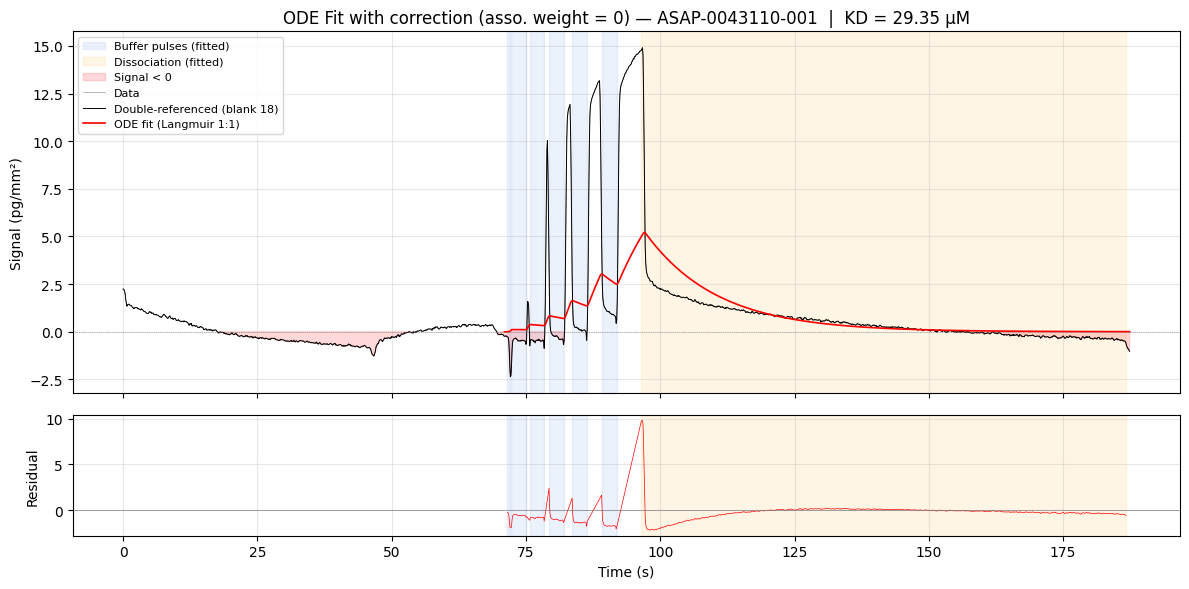

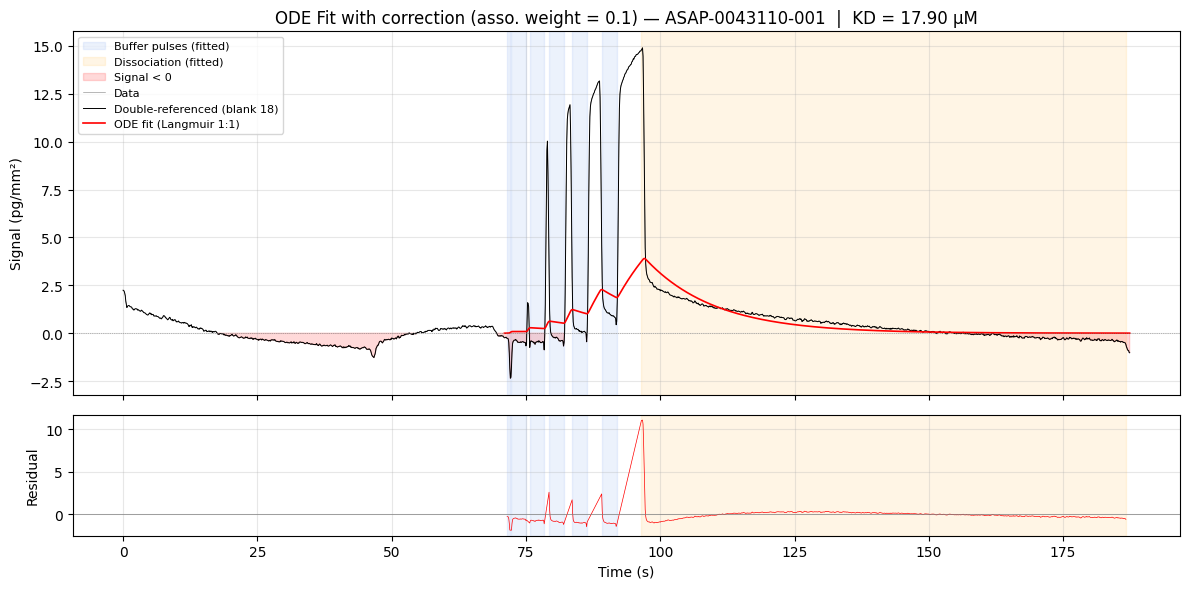

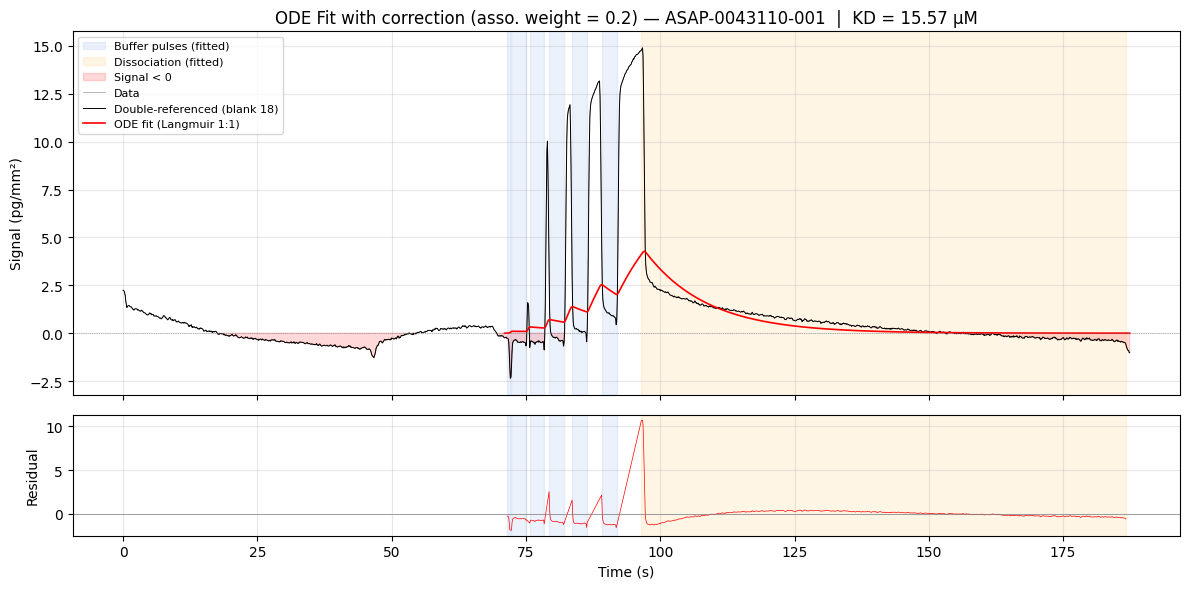

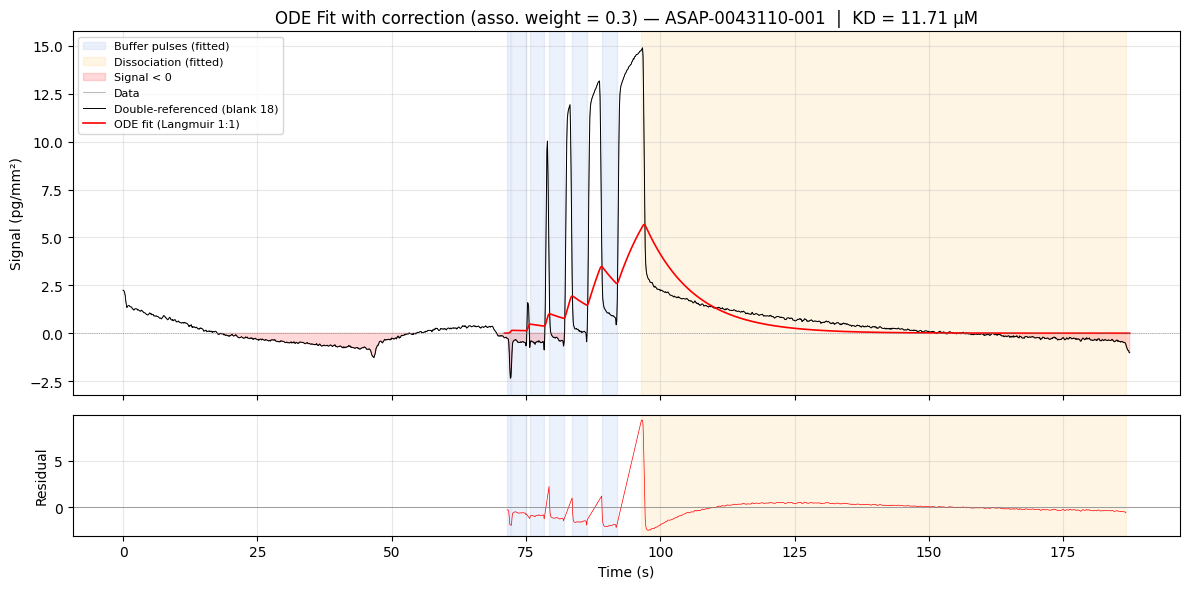

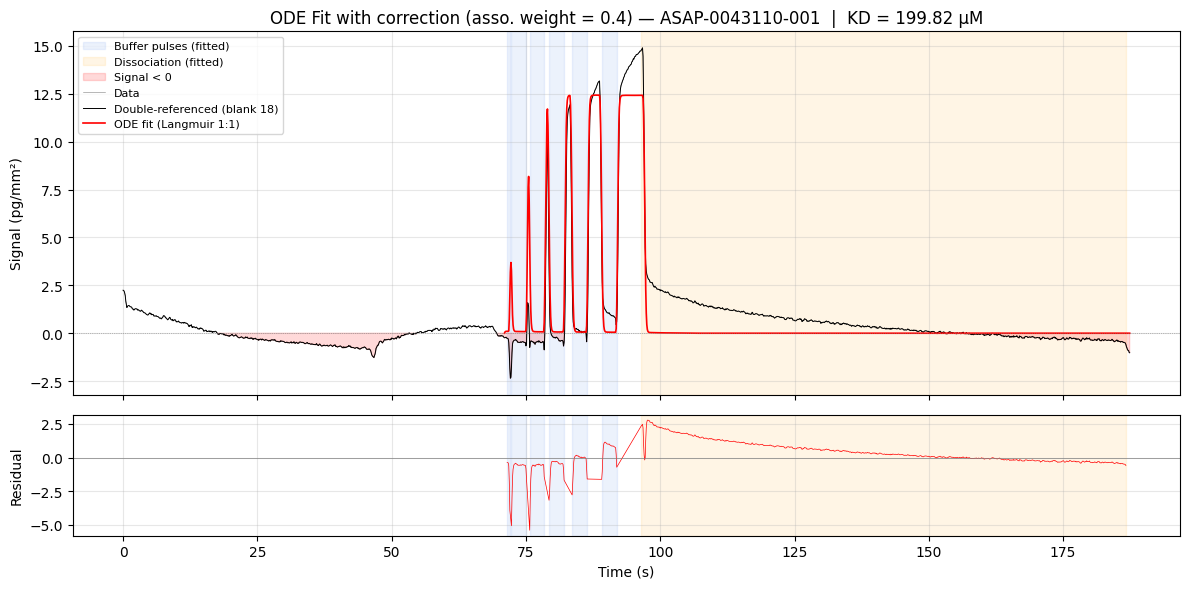

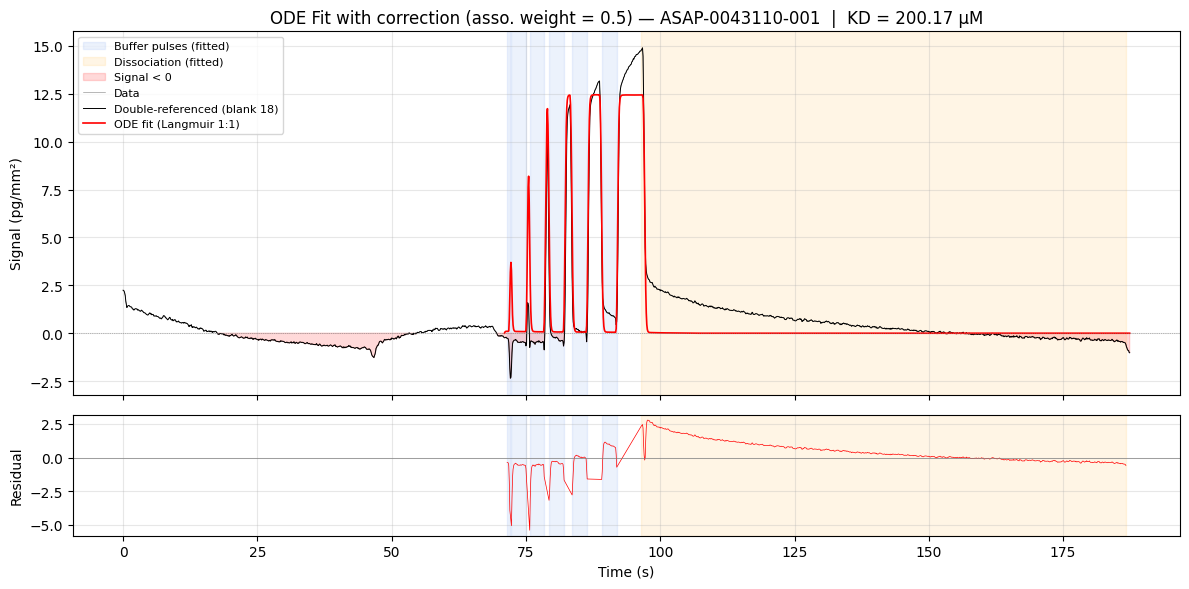

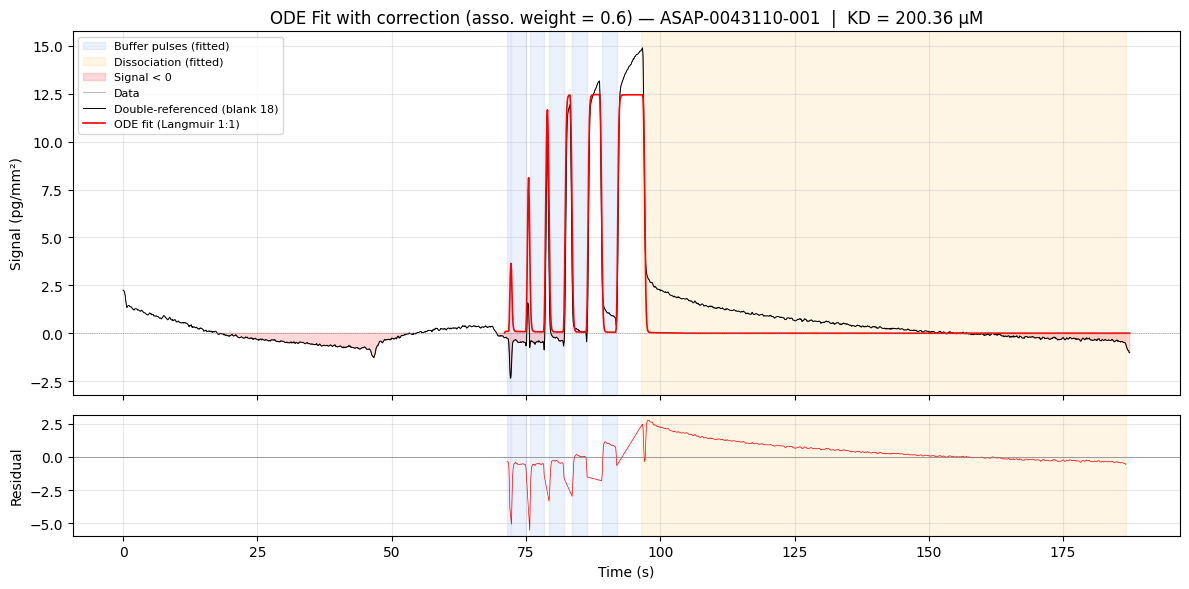

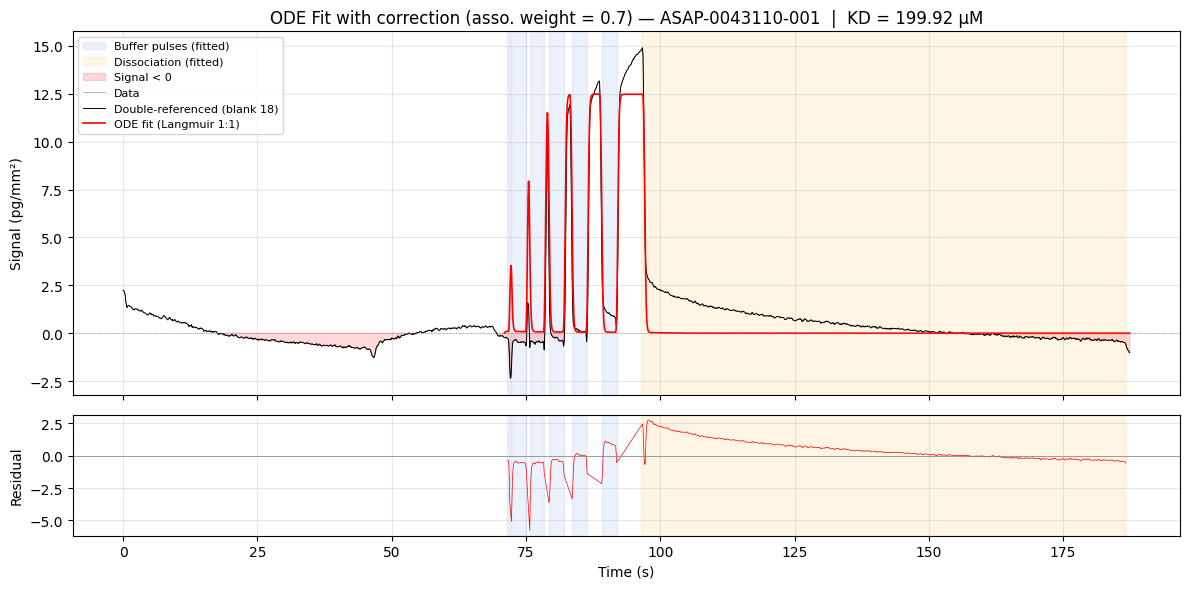

In [ ]:
data_weights = {"ka": [], "ka_se": [], "kd": [], "kd_se": [], "KD": [],
                "Rmax": [], "Rmax_se": [], "Chi2": [], "Chi2_diss": [], "Chi2_asso": [],
                "R2": [], "R2_diss": [], "R2_asso": [], "RMSE": [],
                "RMSE_diss": [], "RMSE_asso": [], "Weight": []}
weights = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
for w in weights:
    results = full_ode_process(sample, dmso_cals, blanks, injection_mask, dissociation_mask, weight=w)
    results.append(w)
    for k, r in zip(data_weights.keys(), results):
        data_weights[k].append(r)
print(pd.DataFrame(data_weights))